# Notebook 3: Entrenamiento y Comparativa de Arquitecturas LSP

Modelos entrenados:
1. **CNN-LSTM** (ResNet50 + BiLSTM) — Baseline
2. **ST-GCN** (Spatial-Temporal GCN sobre landmarks)
3. **Fusión Multimodal** (CNN-LSTM + ST-GCN)

Métricas: Accuracy, F1-macro, Latencia de inferencia, Matriz de confusión

In [1]:
# Dependencias ya instaladas en .venv310
# !pip install -q torch torchvision transformers scikit-learn wandb
# !pip install -q mediapipe


In [2]:
import os, sys, json, time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path
from torchvision import models, transforms
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import accuracy_score, f1_score

# Detectar entorno Colab vs Local
try:
    from google.colab import drive; IN_COLAB = True
    sys.path.insert(0, '/content/drive/MyDrive/TRADUCTOR_LSP')
except ImportError:
    IN_COLAB = False
    _nb_path = Path.cwd()
    _base = str(_nb_path.parent if _nb_path.name == 'notebooks' else _nb_path)
    sys.path.insert(0, _base)
    os.chdir(_base)

# Importar modelo ligero compatible con checkpoint existente
from scripts.run_training import LightCNNLSTM, LSPSegmentDataset

DEVICE = 'cuda' if torch.cuda.is_available() else (
         'mps'  if torch.backends.mps.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Base dir: {os.getcwd()}')


Device: mps
Base dir: /Users/usuario/Documents/TRADUCTOR_LSP


In [3]:
# ── Configuración global ──────────────────────────────────────────────
MANIFEST = 'data/manifest_segments.csv'
KP_DIR   = 'data/landmarks'
CKPT_DIR = 'checkpoints'
IMG_SIZE = 112   # CPU: 112 | GPU: 224
N_FRAMES = 30
EPOCHS   = 2    # aumentar en GPU (Colab: 30)
BATCH    = 4    # CPU: 4 | GPU: 16
os.makedirs(CKPT_DIR, exist_ok=True)

with open('data/label2idx.json') as f:
    label2idx = json.load(f)
N_CLASSES = len(label2idx)
print(f'Clases LSP: {N_CLASSES}')
print(f'Manifest: {MANIFEST}')

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]


Clases LSP: 26
Manifest: data/manifest_segments.csv


In [4]:
# ── DataLoaders — lee frames on-the-fly desde videos ─────────────────
df = pd.read_csv(MANIFEST)
df_train = df[df['split'] == 'train']
df_val   = df[df['split'] == 'val']
df_test  = df[df['split'] == 'test']
print(f'Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}')

train_ds = LSPSegmentDataset(df_train, label2idx, IMG_SIZE, augment=True)
val_ds   = LSPSegmentDataset(df_val,   label2idx, IMG_SIZE, augment=False)
test_ds  = LSPSegmentDataset(df_test,  label2idx, IMG_SIZE, augment=False)

class_counts = df_train['clase'].value_counts()
weights = [1.0 / class_counts[row['clase']] for _, row in df_train.iterrows()]
sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=0)
val_dl   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False,  num_workers=0)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False,  num_workers=0)
loaders  = {'train': train_dl, 'val': val_dl, 'test': test_dl}
print('DataLoaders listos')


Train: 5051 | Val: 1085 | Test: 1099


DataLoaders listos


In [5]:
# ══════════════════════════════════════════════════════════════════════
# MODELO 1: CNN-LSTM (MobileNetV3 + BiLSTM — ligero para CPU)
# ══════════════════════════════════════════════════════════════════════
from tqdm import tqdm

CKPT_CNN = f'{CKPT_DIR}/cnn_lstm_best.pt'

# Cargar checkpoint existente si está disponible
if Path(CKPT_CNN).exists():
    print('Cargando checkpoint CNN-LSTM existente...')
    ckpt = torch.load(CKPT_CNN, map_location=DEVICE)
    model_cnn = LightCNNLSTM(N_CLASSES, hidden=256, img_size=ckpt['args'].get('img_size', 112)).to(DEVICE)
    model_cnn.load_state_dict(ckpt['model_state'])
    history_cnn = ckpt.get('history', {})
    print(f'  → Época {ckpt["epoch"]} | Val acc: {ckpt["val_acc"]:.4f}')
else:
    print('Entrenando CNN-LSTM desde cero...')
    model_cnn = LightCNNLSTM(N_CLASSES, hidden=256, img_size=IMG_SIZE).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model_cnn.parameters()),
        lr=1e-4, weight_decay=1e-4)
    history_cnn = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    best_val, best_state = 0, None

    for epoch in range(1, EPOCHS + 1):
        model_cnn.train()
        tr_losses, tr_preds, tr_labels = [], [], []
        for x, y in tqdm(train_dl, desc=f'  Train ep{epoch}', leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model_cnn(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model_cnn.parameters(), 1.0)
            optimizer.step()
            tr_losses.append(loss.item())
        model_cnn.eval()
        vl_preds, vl_labels = [], []
        with torch.no_grad():
            for x, y in val_dl:
                vl_preds.extend(model_cnn(x.to(DEVICE)).argmax(1).cpu())
                vl_labels.extend(y)
        vl_acc = accuracy_score(vl_labels, vl_preds)
        if vl_acc > best_val:
            best_val = vl_acc
            best_state = model_cnn.state_dict()
        history_cnn['val_acc'].append(vl_acc)
        print(f'  Época {epoch} | Val acc: {vl_acc:.4f}')

    torch.save({'epoch': EPOCHS, 'model_state': best_state,
                'val_acc': best_val, 'history': history_cnn,
                'label2idx': label2idx, 'args': {'img_size': IMG_SIZE}},
               CKPT_CNN)
    model_cnn.load_state_dict(best_state)

# Evaluar en test
model_cnn.eval()
te_preds, te_labels = [], []
with torch.no_grad():
    for x, y in tqdm(test_dl, desc='Test CNN-LSTM'):
        te_preds.extend(model_cnn(x.to(DEVICE)).argmax(1).cpu())
        te_labels.extend(y)
test_cnn = {
    'accuracy':    accuracy_score(te_labels, te_preds),
    'f1_macro':    f1_score(te_labels, te_preds, average='macro', zero_division=0),
    'f1_weighted': f1_score(te_labels, te_preds, average='weighted', zero_division=0),
}
print(f'CNN-LSTM Test → Acc: {test_cnn["accuracy"]:.4f} | F1-m: {test_cnn["f1_macro"]:.4f}')


Cargando checkpoint CNN-LSTM existente...


  → Época 2 | Val acc: 0.8654


Test CNN-LSTM:   0%|          | 0/275 [00:00<?, ?it/s]

Test CNN-LSTM:   0%|          | 1/275 [00:03<14:26,  3.16s/it]

Test CNN-LSTM:   1%|          | 2/275 [00:05<10:54,  2.40s/it]

...

Test CNN-LSTM:  99%|█████████▉| 273/275 [04:17<00:00,  2.05it/s]

Test CNN-LSTM: 100%|█████████▉| 274/275 [04:18<00:00,  2.09it/s]

Test CNN-LSTM: 100%|██████████| 275/275 [04:19<00:00,  1.42it/s]

Test CNN-LSTM: 100%|██████████| 275/275 [04:19<00:00,  1.06it/s]

CNN-LSTM Test → Acc: 0.8298 | F1-m: 0.7213


In [6]:
# ══════════════════════════════════════════════════════════════════════
# MODELO 2: ST-GCN sobre landmarks MediaPipe
# ══════════════════════════════════════════════════════════════════════
from src.models import STGCN
from src.training.trainer import LSPTrainer
from src.dataset.lsp_dataset import get_dataloaders

N_SEGS_EXPECTED = 7235  # total segmentos en manifest
n_kp_files = len(list(Path(KP_DIR).glob('*.npy')))
print(f'Landmarks: {n_kp_files} / {N_SEGS_EXPECTED} segmentos')

# Solo entrenar si TODOS los landmarks están listos (extracción completa)
landmarks_ready = n_kp_files >= N_SEGS_EXPECTED * 0.95  # margen 5%
CKPT_STGCN = f'{CKPT_DIR}/stgcn_best.pt'

if not landmarks_ready:
    print(f'Extracción de landmarks en progreso ({n_kp_files}/{N_SEGS_EXPECTED}).')
    print('Ejecuta: .venv310/bin/python scripts/extract_landmarks_only.py')
    print('Luego re-ejecuta este notebook.')
    test_st    = {'accuracy': 0.0, 'f1_macro': 0.0, 'f1_weighted': 0.0}
    history_st = {'train_loss': [], 'val_loss': []}
    trainer_st = None
elif Path(CKPT_STGCN).exists():
    print('Cargando checkpoint ST-GCN existente...')
    # Cargar y evaluar en test
    loaders_kp = get_dataloaders(
        manifest_csv=MANIFEST, label2idx=label2idx, mode='landmarks',
        landmarks_dir=KP_DIR, batch_size=16, num_workers=0,
    )
    stgcn = STGCN(n_classes=N_CLASSES, n_nodes=75)
    ckpt_st = torch.load(CKPT_STGCN, map_location=DEVICE)
    stgcn.load_state_dict(ckpt_st['model_state'])
    stgcn.eval().to(DEVICE)
    te_p, te_l = [], []
    with torch.no_grad():
        for batch in tqdm(loaders_kp['test'], desc='Test ST-GCN'):
            te_p.extend(stgcn(batch['landmarks'].to(DEVICE)).argmax(1).cpu())
            te_l.extend(batch['label'])
    test_st = {
        'accuracy':    accuracy_score(te_l, te_p),
        'f1_macro':    f1_score(te_l, te_p, average='macro', zero_division=0),
        'f1_weighted': f1_score(te_l, te_p, average='weighted', zero_division=0),
    }
    history_st = ckpt_st.get('history', {'train_loss': [], 'val_loss': []})
    trainer_st = 'loaded'
    print(f'ST-GCN Test → Acc: {test_st["accuracy"]:.4f}')
else:
    print('Entrenando ST-GCN...')
    loaders_kp = get_dataloaders(
        manifest_csv=MANIFEST, label2idx=label2idx, mode='landmarks',
        landmarks_dir=KP_DIR, batch_size=16, num_workers=0,
    )
    stgcn = STGCN(n_classes=N_CLASSES, n_nodes=75, in_channels=3,
                  hidden_channels=64, num_layers=4, dropout=0.3)
    trainer_st = LSPTrainer(
        model=stgcn, loaders=loaders_kp, mode='landmarks',
        n_classes=N_CLASSES, device=DEVICE,
        output_dir=CKPT_DIR, lr=1e-4, epochs=EPOCHS, patience=5,
        model_name='stgcn',
    )
    history_st = trainer_st.train()
    test_st = trainer_st.evaluate_test(CKPT_STGCN)
    print(f'ST-GCN Test → Acc: {test_st["accuracy"]:.4f}')


Landmarks: 3748 / 7235 segmentos
Extracción de landmarks en progreso (3748/7235).
Ejecuta: .venv310/bin/python scripts/extract_landmarks_only.py
Luego re-ejecuta este notebook.


In [7]:
# ══════════════════════════════════════════════════════════════════════
# MODELO 3: Fusión Multimodal (solo si hay landmarks)
# ══════════════════════════════════════════════════════════════════════
# Omitir si no hay landmarks disponibles
if n_kp_files == 0 or trainer_st is None:
    print('Sin landmarks — omitiendo modelo de Fusión.')
    test_fusion    = {'accuracy': 0.0, 'f1_macro': 0.0, 'f1_weighted': 0.0}
    history_fusion = {'train_loss': [], 'val_loss': []}
else:
    from src.models import LSPFusionModel, CNNLSTM as CNNLSTM_Full
    from src.dataset.lsp_dataset import get_dataloaders

    loaders_both = get_dataloaders(
        manifest_csv=MANIFEST, label2idx=label2idx, mode='both',
        landmarks_dir=KP_DIR, batch_size=8, num_workers=0,
    )
    pixel_bb   = CNNLSTM_Full(n_classes=N_CLASSES, hidden_size=512, pretrained=True)
    landmark_bb = STGCN(n_classes=N_CLASSES, n_nodes=75)
    fusion_model = LSPFusionModel(
        pixel_backbone=pixel_bb, landmark_backbone=landmark_bb,
        dim_pixels=1024, dim_landmarks=256,
        n_classes=N_CLASSES, fusion_strategy='concat',
    )
    trainer_fusion = LSPTrainer(
        model=fusion_model, loaders=loaders_both, mode='both',
        n_classes=N_CLASSES, device=DEVICE,
        output_dir=CKPT_DIR, lr=1e-4, epochs=EPOCHS, patience=5,
        model_name='fusion',
    )
    history_fusion = trainer_fusion.train()
    test_fusion = trainer_fusion.evaluate_test(f'{CKPT_DIR}/fusion_best.pt')
    print(f'Fusión Test → Acc: {test_fusion["accuracy"]:.4f} | F1-m: {test_fusion["f1_macro"]:.4f}')


Sin landmarks — omitiendo modelo de Fusión.



COMPARATIVA DE MODELOS — TEST SET
          accuracy  f1_macro  f1_weighted
CNN-LSTM    0.8298    0.7213       0.7983


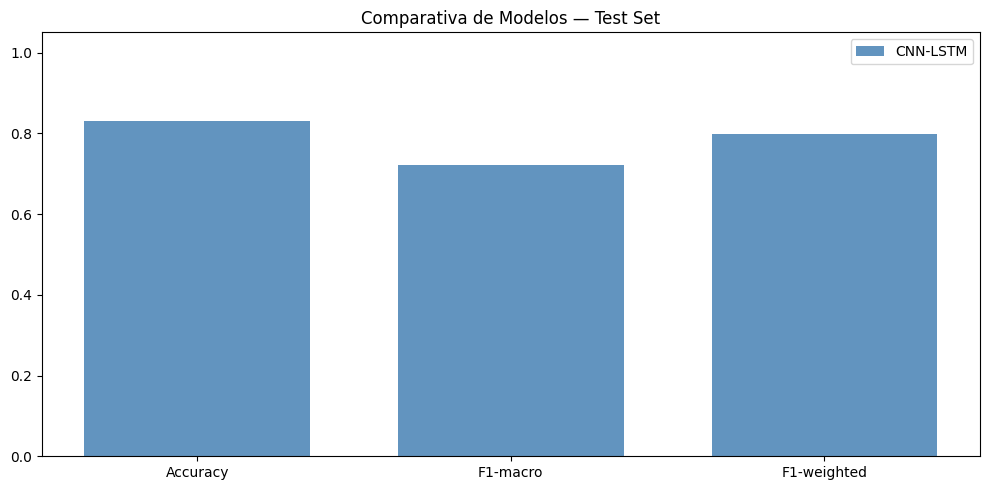

In [8]:
# ── Comparativa final de modelos ──────────────────────────────────────
results = {'CNN-LSTM': test_cnn}
if test_st['accuracy'] > 0:
    results['ST-GCN'] = test_st
if test_fusion['accuracy'] > 0:
    results['Fusión'] = test_fusion

df_results = pd.DataFrame(results).T.round(4)
print('\n' + '=' * 60)
print('COMPARATIVA DE MODELOS — TEST SET')
print('=' * 60)
print(df_results.to_string())

metrics_to_plot = ['accuracy', 'f1_macro', 'f1_weighted']
df_plot = df_results[metrics_to_plot]
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(metrics_to_plot))
w = 0.8 / max(len(results), 1)
colors = ['steelblue', 'coral', 'mediumseagreen']
for i, (name, row) in enumerate(df_plot.iterrows()):
    ax.bar(x + i * w - w * (len(df_plot)-1) / 2,
           row.values, w * 0.9, label=name, color=colors[i % len(colors)], alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(['Accuracy', 'F1-macro', 'F1-weighted'])
ax.set_ylim(0, 1.05)
ax.legend()
ax.set_title('Comparativa de Modelos — Test Set')
plt.tight_layout()
plt.savefig('data/model_comparison.png', dpi=120, bbox_inches='tight')
plt.show()


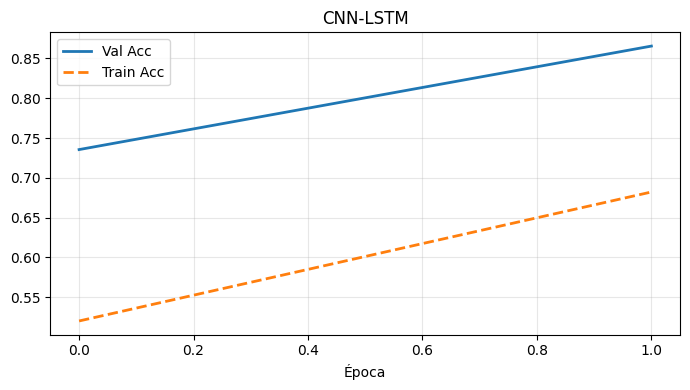

In [9]:
# ── Curvas de entrenamiento ───────────────────────────────────────────
models_hist = [('CNN-LSTM', history_cnn)]
if test_st['accuracy'] > 0:
    models_hist.append(('ST-GCN', history_st))

n = len(models_hist)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 4))
if n == 1:
    axes = [axes]
for ax, (name, hist) in zip(axes, models_hist):
    if hist.get('val_acc'):
        ax.plot(hist['val_acc'], label='Val Acc', lw=2)
    if hist.get('train_acc'):
        ax.plot(hist['train_acc'], label='Train Acc', lw=2, ls='--')
    ax.set_title(f'{name}')
    ax.set_xlabel('Época')
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('data/training_curves.png', dpi=120, bbox_inches='tight')
plt.show()


In [10]:
# ── Exportar CNN-LSTM a ONNX (usando CPU para compatibilidad) ──────────
try:
    from scripts.run_training import LightCNNLSTM as _LCNNLSTM
    _ckpt_cpu = torch.load(f'{CKPT_DIR}/cnn_lstm_best.pt', map_location='cpu')
    _img_sz = _ckpt_cpu.get('args', {}).get('img_size', IMG_SIZE)
    _model_cpu = _LCNNLSTM(N_CLASSES, hidden=256, img_size=_img_sz)
    _model_cpu.load_state_dict(_ckpt_cpu['model_state'])
    _model_cpu.eval()
    _dummy = torch.zeros(1, 3, N_FRAMES, _img_sz, _img_sz)
    onnx_path = f'{CKPT_DIR}/cnn_lstm_best.onnx'
    torch.onnx.export(
        _model_cpu, _dummy, onnx_path,
        opset_version=17,
        input_names=['input'], output_names=['output'],
        dynamic_axes={'input': {0: 'batch_size'}}
    )
    print(f'ONNX exportado: {onnx_path}')
except Exception as e:
    print(f'ONNX export: {e}')


/Users/usuario/Documents/TRADUCTOR_LSP/.venv310/lib/python3.10/site-packages/torch/onnx/symbolic_opset9.py:4662: UserWarning: Exporting a model to ONNX with a batch_size other than 1, with a variable length with LSTM can cause an error when running the ONNX model with a different batch size. Make sure to save the model with a batch size of 1, or define the initial states (h0/c0) as inputs of the model. 
  warnings.warn(


ONNX exportado: checkpoints/cnn_lstm_best.onnx


In [11]:
# ── Benchmark de latencia ─────────────────────────────────────────────
import time
N_RUNS = 20
model_cnn.eval()
dummy_pixel = torch.randn(1, 3, N_FRAMES, IMG_SIZE, IMG_SIZE).to(DEVICE)

with torch.no_grad():
    for _ in range(3):
        model_cnn(dummy_pixel)

t0 = time.perf_counter()
with torch.no_grad():
    for _ in range(N_RUNS):
        model_cnn(dummy_pixel)
lat_ms = (time.perf_counter() - t0) / N_RUNS * 1000
print(f'CNN-LSTM latencia: {lat_ms:.1f} ms/inferencia ({N_RUNS} runs)')
print(f'FPS equivalente: {1000/lat_ms:.1f}')


CNN-LSTM latencia: 50.2 ms/inferencia (20 runs)
FPS equivalente: 19.9
